# ipynb/umap1.ipynb - UMAP 1 / UMAP 1

## 项目背景 / Background
UMAP 1
UMAP 1

## 功能模块 / Modules
- UMAP 嵌入分析 (1)
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: prepare_umap_*.py、ipynb/umap2.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



In [ ]:
# 加载必要库
library(readxl)
library(umap)
library(ggplot2)
library(dplyr)
library(stringr)
library(patchwork)

# --- 1. 莫兰迪配色方案定义 ---
# 12类：高区分度的莫兰迪色
morandi_12 <- c(
  "#8E9775", "#E28E8E", "#94B49F", "#D4BE96", "#827397", "#E9B384",
  "#778D45", "#AEC2B6", "#A7727D", "#557B83", "#E2C2B3", "#6B7B8E"
)

# 4类：经典碱基莫兰迪色
morandi_4 <- c("#91A3B0", "#B8A99A", "#8F9779", "#BA9494")

# 标签名称映射
label_names_12 <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")
label_names_4 <- c("A", "C", "G", "U")

# --- 2. 核心函数：将空格分隔的字符串转换为数值矩阵 ---
str_to_matrix <- function(vec_strings) {
  # 1. 移除可能存在的方括号或多余空格
  clean_strings <- str_squish(str_replace_all(vec_strings, "\\[|\\]", ""))
  # 2. 按空格分割并转为数值列表
  list_data <- str_split(clean_strings, "\\s+") # \\s+ 匹配一个或多个空格
  # 3. 合并为矩阵
  mat <- do.call(rbind, lapply(list_data, as.numeric))
  return(mat)
}

# --- 3. 读取并采样数据 ---
cat("正在读取 Excel 数据...\n")
df_all <- read_excel("human.xlsx")

set.seed(42) # 保证采样可重复

# 分层采样函数
get_sampled_data <- function(data, label_col, n = 1000) {
  data %>%
    group_by(!!sym(label_col)) %>%
    sample_n(size = min(n(), n)) %>%
    ungroup()
}

# --- 4. 处理 12-Class UMAP ---
cat("处理 12-Class 数据中...\n")
df_12 <- get_sampled_data(df_all, "label12", 1000)
mat_12 <- str_to_matrix(df_12$l12)

# 核心：确保输入是矩阵
if(!is.matrix(mat_12)) stop("mat_12 转换失败，请检查 l12 字段格式")

umap_12_res <- umap(mat_12)
plot_df_12 <- data.frame(
  U1 = umap_12_res$layout[,1], 
  U2 = umap_12_res$layout[,2],
  Label = factor(label_names_12[df_12$label12 + 1], levels = label_names_12)
)

# --- 5. 处理 4-Class UMAP (如果 l4 不为空) ---
cat("处理 4-Class 数据中...\n")
df_4 <- get_sampled_data(df_all, "label4", 1000) %>% filter(!is.na(l4))
mat_4 <- str_to_matrix(df_4$l4)

umap_4_res <- umap(mat_4)
plot_df_4 <- data.frame(
  U1 = umap_4_res$layout[,1], 
  U2 = umap_4_res$layout[,2],
  Label = factor(label_names_4[df_4$label4 + 1], levels = label_names_4)
)

# --- 6. 绘图 ---
p1 <- ggplot(plot_df_12, aes(x = U1, y = U2, color = Label)) +
  geom_point(alpha = 0.6, size = 0.5) +
  scale_color_manual(values = morandi_12) +
  labs(title = "12-Class RNA Modification UMAP", subtitle = "Morandi Palette | 1000 samples/class",
       x = "UMAP_1", y = "UMAP_2") +
  theme_minimal() +
  theme(legend.position = "bottom")

p2 <- ggplot(plot_df_4, aes(x = U1, y = U2, color = Label)) +
  geom_point(alpha = 0.6, size = 0.5) +
  scale_color_manual(values = morandi_4) +
  labs(title = "4-Class Nucleotide UMAP", subtitle = "Morandi Palette | 1000 samples/class",
       x = "UMAP_1", y = "UMAP_2") +
  theme_minimal() +
  theme(legend.position = "bottom")

# 合并展示
final_plot <- p1 + p2 + plot_layout(ncol = 2)
print(final_plot)

# 保存为论文高质量图片 (TIFF 格式)
ggsave("UMAP_Combined.pdf", final_plot, width = 12, height = 6)

In [ ]:
library(readxl)
library(umap)
library(ggplot2)
library(dplyr)
library(stringr)
library(MASS) # 用于线性判别分析 (LDA)

# --- 1. 严格定义色系（高饱和度：红、绿、蓝、黄） ---
# A组 (红色系 - 5类)
colors_A <- c("#8B0000", "#D32F2F", "#F44336", "#E57373", "#FFCDD2")
# C组 (绿色系 - 3类)
colors_C <- c("#1B5E20", "#388E3C", "#66BB6A")
# G组 (蓝色系 - 2类)
colors_G <- c("#0D47A1", "#1976D2")
# U组 (黄色系 - 2类)
colors_U <- c("#FBC02D", "#FFF176")

# 12类名称
label_names_12 <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")

# --- 2. 建立具名颜色映射表 (解决映射错误的核心) ---
# 定义每个 Label 属于哪个组
group_info <- list(
  "A" = c("Am", "Atol", "m1A", "m6A", "m6Am"),
  "C" = c("Cm", "ac4C", "m5C"),
  "G" = c("Gm", "m7G"),
  "U" = c("Tm", "Y")
)

# 构造具名向量，例如 "A: Am" -> "#8B0000"
color_map <- c()
for(g in names(group_info)) {
  sub_labels <- group_info[[g]]
  # 获取对应组的颜色
  g_colors <- switch(g, "A"=colors_A, "C"=colors_C, "G"=colors_G, "U"=colors_U)
  for(i in 1:length(sub_labels)) {
    full_name <- paste0(g, ": ", sub_labels[i])
    color_map[full_name] <- g_colors[i]
  }
}

# --- 3. 数据处理与采样 ---
df_all <- read_excel("human.xlsx")

str_to_matrix <- function(vec) {
  do.call(rbind, lapply(str_split(str_squish(str_replace_all(vec, "\\[|\\]", "")), "\\s+"), as.numeric))
}

set.seed(42)
df_sampled <- df_all %>%
  group_by(label12) %>%
  sample_n(size = min(n(), 1000)) %>%
  ungroup() %>%
  mutate(Group4 = case_when(
    label12 %in% c(0, 1, 7, 9, 10) ~ "A",
    label12 %in% c(2, 6, 8) ~ "C",
    label12 %in% c(3, 11) ~ "G",
    label12 %in% c(4, 5) ~ "U"
  ))

# 计算 UMAP
mat_12 <- str_to_matrix(df_sampled$l12)
umap_res <- umap(mat_12)

# 构建绘图框，并设置 LegendLabel 的 Factor 顺序
plot_df <- data.frame(
  U1 = umap_res$layout[,1], 
  U2 = umap_res$layout[,2],
  Label12 = label_names_12[df_sampled$label12 + 1],
  Group4 = factor(df_sampled$Group4, levels = c("A", "C", "G", "U"))
) %>%
  mutate(LegendLabel = factor(paste0(Group4, ": ", Label12), levels = names(color_map)))

# --- 4. 计算 4-Class 线性决策边界 ---
lda_model <- lda(Group4 ~ U1 + U2, data = plot_df)
grid_size <- 500
u1_range <- seq(min(plot_df$U1)-2, max(plot_df$U1)+2, length.out = grid_size)
u2_range <- seq(min(plot_df$U2)-2, max(plot_df$U2)+2, length.out = grid_size)
grid <- expand.grid(U1 = u1_range, U2 = u2_range)
grid$pred_num <- as.numeric(predict(lda_model, grid)$class)

# --- 5. 绘图 ---
p <- ggplot() +
  # 12-class 散点 (使用具名向量映射颜色)
  geom_point(data = plot_df, aes(x = U1, y = U2, color = LegendLabel), 
             size = 1.5, alpha = 0.4) +
  scale_color_manual(values = color_map, name = "RNA Modifications") +
  
  # 4-class 线性决策边界线 (使用 geom_contour 提取边界)
  geom_contour(data = grid, aes(x = U1, y = U2, z = pred_num),
               breaks = c(1.5, 2.5, 3.5), 
               color = "black", linewidth = 1, linetype = "solid") +
  
  theme_minimal() +
  labs(title = "RGCNFormer Feature Space (12-Class UMAP)",
       subtitle = "Colors: A(Red), C(Green), G(Blue), U(Yellow) | Lines: 4-Class Linear Boundaries",
       x = "UMAP dimension 1", y = "UMAP dimension 2") +
  
  # 优化图例
  guides(color = guide_legend(override.aes = list(size = 5, alpha = 1), ncol = 2)) +
  theme(
    legend.position = "right",
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    plot.title = element_text(face = "bold", size = 16),
    legend.text = element_text(size = 11)
  )

print(p)

# 保存最终版本
ggsave("RGCNFormer_Vibrant_Final.pdf", p, width = 12, height = 8)


Attaching package: 'umap'


The following object is masked from 'package:uwot':

    umap



Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select




In [ ]:
library(readxl)
library(uwot)      # 替换 library(umap)
library(ggplot2)
library(dplyr)
library(stringr)

# --- 1. 定义莫兰迪色系 (保持不变) ---
morandi_colors <- c(
  "#A6A5C4", "#C4A5A6", "#A6C4A5", "#C4C4A5", "#9FB6CD", "#CDB39F",
  "#B3CD9F", "#CDCDB3", "#E6C8C3", "#C3E6C8", "#C8C3E6", "#E6E0C3"
)
label_names_12 <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")
names(morandi_colors) <- label_names_12

# --- 2. 数据处理与采样 (保持不变) ---
df_all <- read_excel("human.xlsx")

str_to_matrix <- function(vec) {
  do.call(rbind, lapply(str_split(str_squish(str_replace_all(vec, "\\[|\\]", "")), "\\s+"), as.numeric))
}

set.seed(42)
df_sampled <- df_all %>%
  group_by(label12) %>%
  sample_n(size = min(n(), 1000)) %>%
  ungroup()

# --- 3. 使用 uwot 计算 UMAP ---
mat_12 <- str_to_matrix(df_sampled$l12)

# 使用 uwot::umap 
# 注意：uwot 直接返回一个矩阵，而不是像 umap 包那样返回一个包含 layout 的列表
umap_res <- umap(
  mat_12, 
  n_neighbors = 30, 
  min_dist = 0.1, 
  metric = "cosine", # uwot 默认是 euclidean，如果是高维序列特征，cosine 有时效果更好
  n_threads = 4,     # uwot 支持多线程并行计算
  verbose = TRUE
)

# 构建基础数据框
# 直接使用 umap_res，因为它本身就是坐标矩阵
base_df <- data.frame(
  U1 = umap_res[,1],
  U2 = umap_res[,2],
  ActualLabel = label_names_12[df_sampled$label12 + 1]
)

# --- 4. 数据重构 (One-vs-All 分面准备) ---
expanded_plot_df <- list()

for (target_label in label_names_12) {
  temp_df <- base_df
  temp_df$FacetPanel <- target_label
  temp_df$PlotStatus <- ifelse(temp_df$ActualLabel == target_label, target_label, "Other")
  expanded_plot_df[[target_label]] <- temp_df
}

plot_df_final <- do.call(rbind, expanded_plot_df)
plot_df_final$PlotStatus <- factor(plot_df_final$PlotStatus, levels = c("Other", label_names_12))
plot_df_final$FacetPanel <- factor(plot_df_final$FacetPanel, levels = label_names_12)


# --- 5. 绘图 (保持不变，但优化了保存文件名) ---
p <- ggplot(plot_df_final, aes(x = U1, y = U2)) +
  geom_point(data = subset(plot_df_final, PlotStatus == "Other"),
             color = "#E0E0E0", size = 0.2, alpha = 0.4) +
  geom_point(data = subset(plot_df_final, PlotStatus != "Other"),
             aes(color = PlotStatus), size = 0.6, alpha = 1) +
  scale_color_manual(values = morandi_colors, name = "Active Class") +
  facet_wrap(~FacetPanel, ncol = 4, scales = "fixed") +
  theme_minimal() +
  labs(title = "One-vs-All uwot::UMAP Projections",
       subtitle = "Morandi Palette: Highlighting Active Class vs Others",
       x = "UMAP Dimension 1", y = "UMAP Dimension 2") +
  theme(
    panel.grid = element_blank(),
    strip.text = element_text(face = "bold", size = 11),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.5),
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5, color = "grey40"),
    legend.position = "none"
  )

print(p)

ggsave("uwot_UMAP_Facet_12Class.pdf", p, width = 14, height = 10)

code for methods in class "Rcpp_AnnoyAngular" was not checked for suspicious field assignments (recommended package 'codetools' not available?)

code for methods in class "Rcpp_AnnoyAngular" was not checked for suspicious field assignments (recommended package 'codetools' not available?)

code for methods in class "Rcpp_AnnoyEuclidean" was not checked for suspicious field assignments (recommended package 'codetools' not available?)

code for methods in class "Rcpp_AnnoyEuclidean" was not checked for suspicious field assignments (recommended package 'codetools' not available?)

code for methods in class "Rcpp_AnnoyManhattan" was not checked for suspicious field assignments (recommended package 'codetools' not available?)

code for methods in class "Rcpp_AnnoyManhattan" was not checked for suspicious field assignments (recommended package 'codetools' not available?)

code for methods in class "Rcpp_AnnoyHamming" was not checked for suspicious field assignments (recommended package 'codet

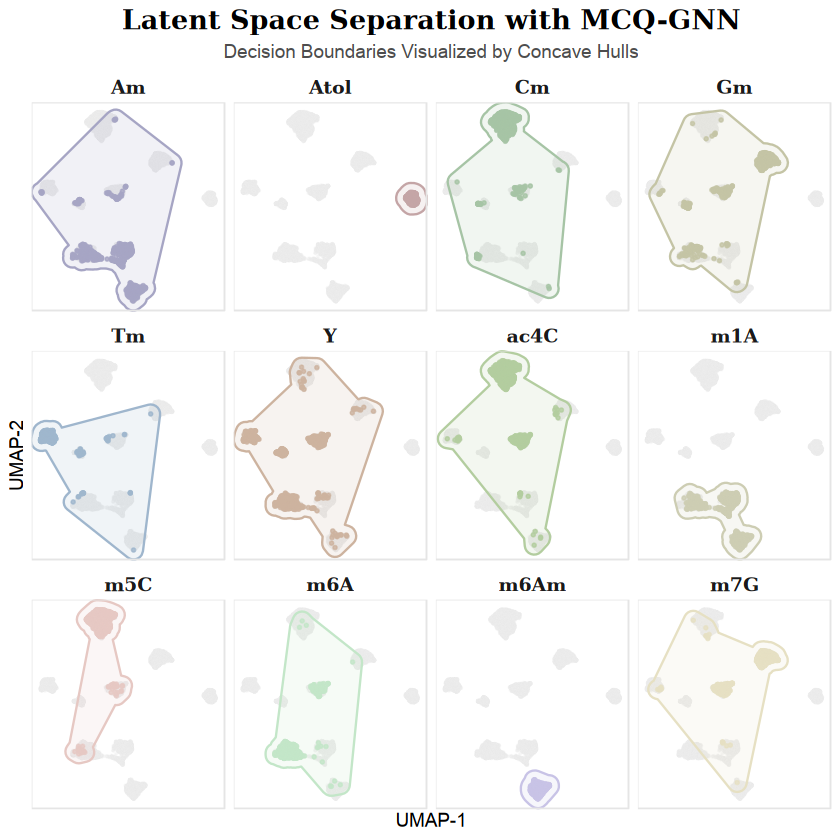

In [5]:
# 确保安装了 ggalt: install.packages("ggalt")
library(readxl)
library(uwot)
library(ggplot2)
library(dplyr)
library(stringr)
library(ggforce) # 替代 ggalt

# --- 1. 定义莫兰迪色系 (保持不变) ---
morandi_colors <- c(
  "#A6A5C4", "#C4A5A6", "#A6C4A5", "#C4C4A5", "#9FB6CD", "#CDB39F",
  "#B3CD9F", "#CDCDB3", "#E6C8C3", "#C3E6C8", "#C8C3E6", "#E6E0C3"
)
label_names_12 <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")
names(morandi_colors) <- label_names_12

# --- 2. 数据处理与采样 ---
df_all <- read_excel("human.xlsx")

str_to_matrix <- function(vec) {
  do.call(rbind, lapply(str_split(str_squish(str_replace_all(vec, "\\[|\\]", "")), "\\s+"), as.numeric))
}

set.seed(42)
df_sampled <- df_all %>%
  group_by(label12) %>%
  sample_n(size = min(n(), 1000)) %>%
  ungroup()

# --- 3. 使用 uwot 计算 UMAP ---
mat_12 <- str_to_matrix(df_sampled$l12)
umap_res <- umap(mat_12, n_neighbors = 30, min_dist = 0.1, metric = "cosine", n_threads = 4)

base_df <- data.frame(
  U1 = umap_res[,1],
  U2 = umap_res[,2],
  ActualLabel = label_names_12[df_sampled$label12 + 1]
)

# --- 4. 数据重构 (One-vs-All) ---
expanded_plot_df <- list()
for (target_label in label_names_12) {
  temp_df <- base_df
  temp_df$FacetPanel <- target_label
  temp_df$PlotStatus <- ifelse(temp_df$ActualLabel == target_label, target_label, "Other")
  expanded_plot_df[[target_label]] <- temp_df
}
plot_df_final <- do.call(rbind, expanded_plot_df)
plot_df_final$PlotStatus <- factor(plot_df_final$PlotStatus, levels = c("Other", label_names_12))
plot_df_final$FacetPanel <- factor(plot_df_final$FacetPanel, levels = label_names_12)

# --- 5. 绘图 (集成 ggforce::geom_mark_hull) ---
p <- ggplot(plot_df_final, aes(x = U1, y = U2)) +
  # 背景层：全量灰色点
  geom_point(data = subset(plot_df_final, PlotStatus == "Other"),
             color = "#EBEBEB", size = 0.15, alpha = 0.3) +
  
  # 关键层：使用 ggforce 画出平滑的决策边界
  # concavity 参数控制边界的“紧缩”程度，数值越大越贴合点的形状
  geom_mark_hull(data = subset(plot_df_final, PlotStatus != "Other"),
                 aes(color = PlotStatus, fill = PlotStatus),
                 concavity = 5,       # 核心参数：控制边界紧贴程度
                 expand = unit(2, "mm"), # 边界向外扩张的距离
                 radius = unit(2, "mm"), # 拐角圆润度
                 alpha = 0.15, 
                 size = 0.5, 
                 show.legend = FALSE) +
  
  # 前景层：当前类的着色点
  geom_point(data = subset(plot_df_final, PlotStatus != "Other"),
             aes(color = PlotStatus), size = 0.5, alpha = 0.8) +
  
  scale_color_manual(values = morandi_colors) +
  scale_fill_manual(values = morandi_colors) +
  
  facet_wrap(~FacetPanel, ncol = 4, scales = "fixed") +
  theme_minimal() +
  labs(title = "Latent Space Separation with MCQ-GNN",
       subtitle = "Decision Boundaries Visualized by Concave Hulls",
       x = "UMAP-1", y = "UMAP-2") +
  theme(
    panel.grid = element_blank(),
    strip.text = element_text(face = "bold", size = 11, family = "serif"),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.border = element_rect(color = "grey90", fill = NA, linewidth = 0.4),
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5, family = "serif"),
    plot.subtitle = element_text(hjust = 0.5, color = "grey30"),
    legend.position = "none"
  )

print(p)

ggsave("UMAP_Decision_Boundary_Morandi.pdf", p, width = 15, height = 11)

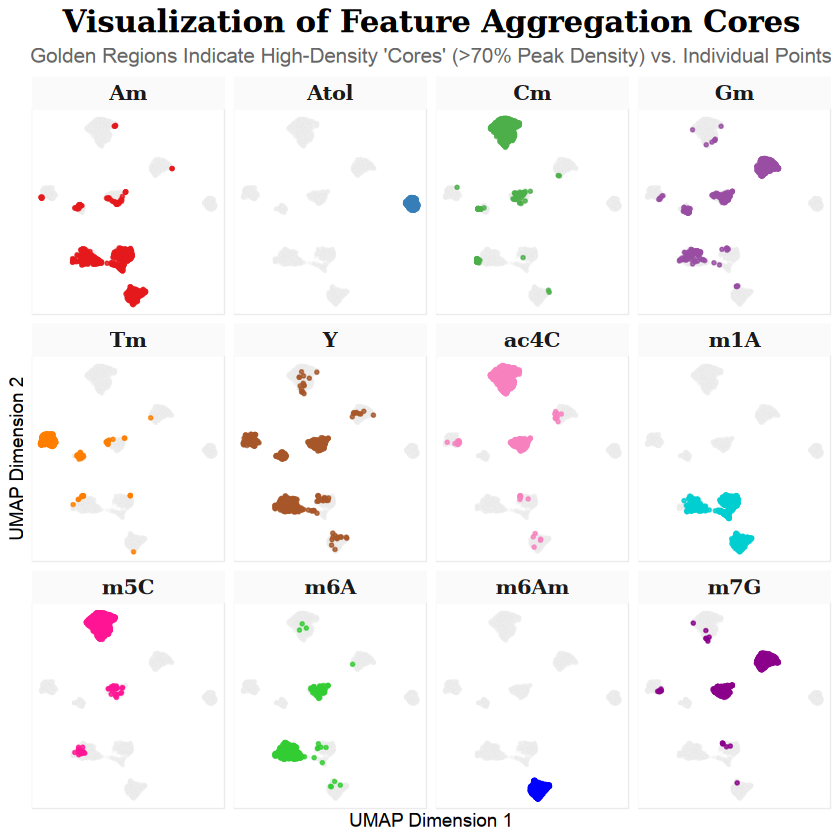

In [12]:
library(readxl)
library(uwot)
library(ggplot2)
library(dplyr)
library(stringr)
library(scales) # 需要加载 scales 包来使用 squish 功能

# --- 1. 定义配色方案 ---
# A. 点的配色 (保持之前的鲜明色系不变)
distinct_colors <- c(
  "#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#A65628",
  "#F781BF", "#00CED1", "#FF1493", "#32CD32", "#0000FF", "#8B008B" # 把黄色替换掉，防止和核心色冲突
)
label_names_12 <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")
names(distinct_colors) <- label_names_12

# B. 核心密度的单一高光色 (定义一个极明显的颜色，如亮金黄)
core_highlight_color <- "#FFD700" # Gold

# --- 2. 数据处理与采样 ---
df_all <- read_excel("human.xlsx")

str_to_matrix <- function(vec) {
  do.call(rbind, lapply(str_split(str_squish(str_replace_all(vec, "\\[|\\]", "")), "\\s+"), as.numeric))
}

set.seed(42)
df_sampled <- df_all %>%
  group_by(label12) %>%
  sample_n(size = min(n(), 1000)) %>%
  ungroup()

# --- 3. 使用 uwot 计算 UMAP ---
mat_12 <- str_to_matrix(df_sampled$l12)
umap_res <- umap(mat_12, n_neighbors = 30, min_dist = 0.1, metric = "cosine", n_threads = 4)

base_df <- data.frame(
  U1 = umap_res[,1],
  U2 = umap_res[,2],
  ActualLabel = label_names_12[df_sampled$label12 + 1]
)

# --- 4. 数据重构 (One-vs-All) ---
expanded_plot_df <- list()
for (target_label in label_names_12) {
  temp_df <- base_df
  temp_df$FacetPanel <- target_label
  temp_df$PlotStatus <- ifelse(temp_df$ActualLabel == target_label, target_label, "Other")
  expanded_plot_df[[target_label]] <- temp_df
}
plot_df_final <- do.call(rbind, expanded_plot_df)
plot_df_final$FacetPanel <- factor(plot_df_final$FacetPanel, levels = label_names_12)

# --- 5. 绘图：高光核心 + 原始配色点 ---
p <- ggplot(plot_df_final, aes(x = U1, y = U2)) +
  # A. 背景层：极淡的灰色散点
  geom_point(data = subset(plot_df_final, PlotStatus == "Other"),
             color = "#F0F0F0", size = 0.1, alpha = 0.1) +
  
  # B. 【关键修改】核心密度层：统一使用高光色，且只显示高密度区
  stat_density_2d(
    data = subset(plot_df_final, PlotStatus != "Other"),
    aes(alpha = after_stat(nlevel)), # 将归一化密度映射到透明度
    geom = "polygon",
    fill = core_highlight_color,     # <--- 核心全部填充为单一高光色
    color = NA,                      # 不画边缘线
    bins = 15,                       # 计算精度
    h = c(1.0, 1.0)                  # 带宽：调小会让核心更紧致
  ) +
  
  # C. 前景层：实际的点，保持原来的分类配色
  geom_point(data = subset(plot_df_final, PlotStatus != "Other"),
             aes(color = PlotStatus), # <--- 点的颜色依然映射到类别
             size = 0.5, alpha = 0.8) +
  
  # 配色映射
  scale_color_manual(values = distinct_colors) +
  
  # 【核心技巧】透明度截断控制
  # 解释：nlevel 范围是 0-1。我们设置 limits = c(0.7, 1.0)
  # 意味着只有密度达到最高峰 70% 以上的区域才会被赋予透明度。
  # oob = scales::squish 确保低于 0.7 的区域 alpha 强制为 0 (完全不可见)。
  # range = c(0.5, 0.9) 确保显示出来的核心既有层次感，又足够实。
  scale_alpha_continuous(limits = c(0.7, 1.0), range = c(0.5, 0.9), oob = scales::squish, guide = "none") +
  
  facet_wrap(~FacetPanel, ncol = 4, scales = "fixed") +
  theme_minimal() +
  labs(title = "Visualization of Feature Aggregation Cores",
       subtitle = "Golden Regions Indicate High-Density 'Cores' (>70% Peak Density) vs. Individual Points",
       x = "UMAP Dimension 1", y = "UMAP Dimension 2") +
  theme(
    panel.grid = element_blank(),
    panel.background = element_rect(fill = "white", color = NA),
    strip.text = element_text(face = "bold", size = 12, family = "serif"),
    strip.background = element_rect(fill = "#FAFAFA", color = NA),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.border = element_rect(color = "grey92", fill = NA, linewidth = 0.3),
    plot.title = element_text(face = "bold", size = 18, hjust = 0.5, family = "serif"),
    plot.subtitle = element_text(hjust = 0.5, color = "grey40", size = 12),
    legend.position = "none"
  )

print(p)

ggsave("UMAP_Decision_Boundary_Morandi.pdf", p, width = 15, height = 11)

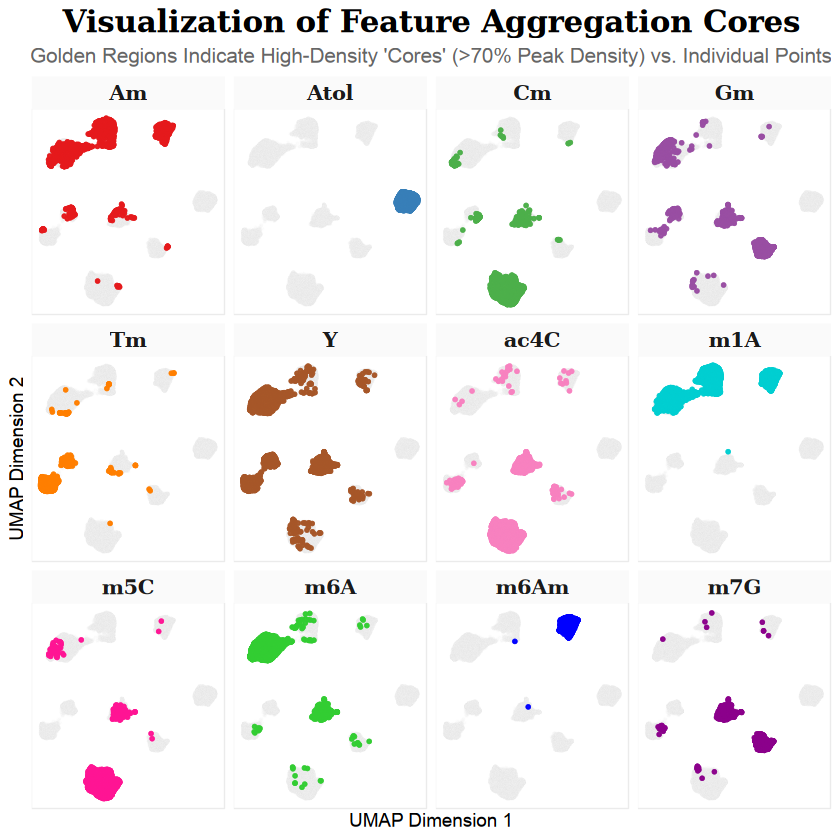

In [ ]:
library(readxl)
library(uwot)
library(ggplot2)
library(dplyr)
library(stringr)
library(scales) # 需要加载 scales 包来使用 squish 功能

# --- 1. 定义配色方案 ---
# A. 点的配色 (保持之前的鲜明色系不变)
distinct_colors <- c(
  "#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#A65628",
  "#F781BF", "#00CED1", "#FF1493", "#32CD32", "#0000FF", "#8B008B" # 把黄色替换掉，防止和核心色冲突
)
label_names_12 <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")
names(distinct_colors) <- label_names_12

# B. 核心密度的单一高光色 (定义一个极明显的颜色，如亮金黄)
core_highlight_color <- "#FFD700" # Gold

# --- 2. 数据处理与采样 ---
df_all <- read_excel("human.xlsx")

str_to_matrix <- function(vec) {
  do.call(rbind, lapply(str_split(str_squish(str_replace_all(vec, "\\[|\\]", "")), "\\s+"), as.numeric))
}

set.seed(42)
df_sampled <- df_all %>%
  group_by(label12) %>%
  sample_n(size = min(n(), 1000)) %>%
  ungroup()

# --- 3. 使用 uwot 计算 UMAP ---
mat_12 <- str_to_matrix(df_sampled$l12)
umap_res <- umap(mat_12, n_neighbors = 30, min_dist = 0.1, metric = "cosine", n_threads = 4)

base_df <- data.frame(
  U1 = umap_res[,1],
  U2 = umap_res[,2],
  ActualLabel = label_names_12[df_sampled$label12 + 1]
)

# --- 4. 数据重构 (One-vs-All) ---
expanded_plot_df <- list()
for (target_label in label_names_12) {
  temp_df <- base_df
  temp_df$FacetPanel <- target_label
  temp_df$PlotStatus <- ifelse(temp_df$ActualLabel == target_label, target_label, "Other")
  expanded_plot_df[[target_label]] <- temp_df
}
plot_df_final <- do.call(rbind, expanded_plot_df)
plot_df_final$FacetPanel <- factor(plot_df_final$FacetPanel, levels = label_names_12)

# --- 5. 绘图：调整顺序让金色核心置顶 ---
p <- ggplot(plot_df_final, aes(x = U1, y = U2)) +
  # A. 背景层：最底层，极淡的灰色散点
  geom_point(data = subset(plot_df_final, PlotStatus == "Other"),
             color = "#F0F0F0", size = 0.1, alpha = 0.1) +
  
  # B. 前景层：中间层，实际的分类颜色点
  geom_point(data = subset(plot_df_final, PlotStatus != "Other"),
             aes(color = PlotStatus), 
             size = 0.5, alpha = 0.8) +
  
#   # C. 【关键修改】核心密度层：移动到最后，确保它覆盖在点之上
#   stat_density_2d(
#     data = subset(plot_df_final, PlotStatus != "Other"),
#     aes(alpha = after_stat(nlevel)), 
#     geom = "polygon",
#     fill = core_highlight_color,     # 金色
#     color = NA,                      
#     bins = 15,                       
#     h = c(1.0, 1.0)                  
#   ) +
  
  # C. 前景层：实际的点，保持原来的分类配色
  geom_point(data = subset(plot_df_final, PlotStatus != "Other"),
             aes(color = PlotStatus), # <--- 点的颜色依然映射到类别
             size = 1.5, alpha = 0.4) +
  
  # 配色映射
  scale_color_manual(values = distinct_colors) +
  
  # 【核心技巧】透明度截断控制
  # 解释：nlevel 范围是 0-1。我们设置 limits = c(0.7, 1.0)
  # 意味着只有密度达到最高峰 70% 以上的区域才会被赋予透明度。
  # oob = scales::squish 确保低于 0.7 的区域 alpha 强制为 0 (完全不可见)。
  # range = c(0.5, 0.9) 确保显示出来的核心既有层次感，又足够实。
  scale_alpha_continuous(limits = c(0.7, 1.0), range = c(0.5, 0.9), oob = scales::squish, guide = "none") +
  
  facet_wrap(~FacetPanel, ncol = 4, scales = "fixed") +
  theme_minimal() +
  labs(title = "Visualization of Feature Aggregation Cores",
       subtitle = "Golden Regions Indicate High-Density 'Cores' (>70% Peak Density) vs. Individual Points",
       x = "UMAP Dimension 1", y = "UMAP Dimension 2") +
  theme(
    panel.grid = element_blank(),
    panel.background = element_rect(fill = "white", color = NA),
    strip.text = element_text(face = "bold", size = 12, family = "serif"),
    strip.background = element_rect(fill = "#FAFAFA", color = NA),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.border = element_rect(color = "grey92", fill = NA, linewidth = 0.3),
    plot.title = element_text(face = "bold", size = 18, hjust = 0.5, family = "serif"),
    plot.subtitle = element_text(hjust = 0.5, color = "grey40", size = 12),
    legend.position = "none"
  )

print(p)

ggsave("UMAP_Decision_Boundary_Morandi.pdf", p, width = 15, height = 11)